In [ ]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt

# Connect to PostgreSQL
conn = psycopg2.connect(
    dbname="toronto_food_analytics",
    user = "kevindai"   
) 

print("Connected")

Connected


In [3]:
# Query top 10 cusisines
query = """ 
    SELECT cuisine, COUNT(*) as total
    FROM restaurants 
    WHERE cuisine IS NOT NULL   
    GROUP BY cuisine
    ORDER BY total DESC
    LIMIT 10;
"""

df_cuisine = pd.read_sql(query, conn)
print(df_cuisine)

       cuisine  total
0  coffee_shop    865
1        pizza    681
2     sandwich    385
3      chinese    371
4       burger    364
5      chicken    302
6       indian    254
7      mexican    215
8        sushi    213
9   bubble_tea    193


/var/folders/q3/lqkxfhqd69scqh0r94mkbdm00000gn/T/ipykernel_22960/3900398905.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_cuisine = pd.read_sql(query, conn)


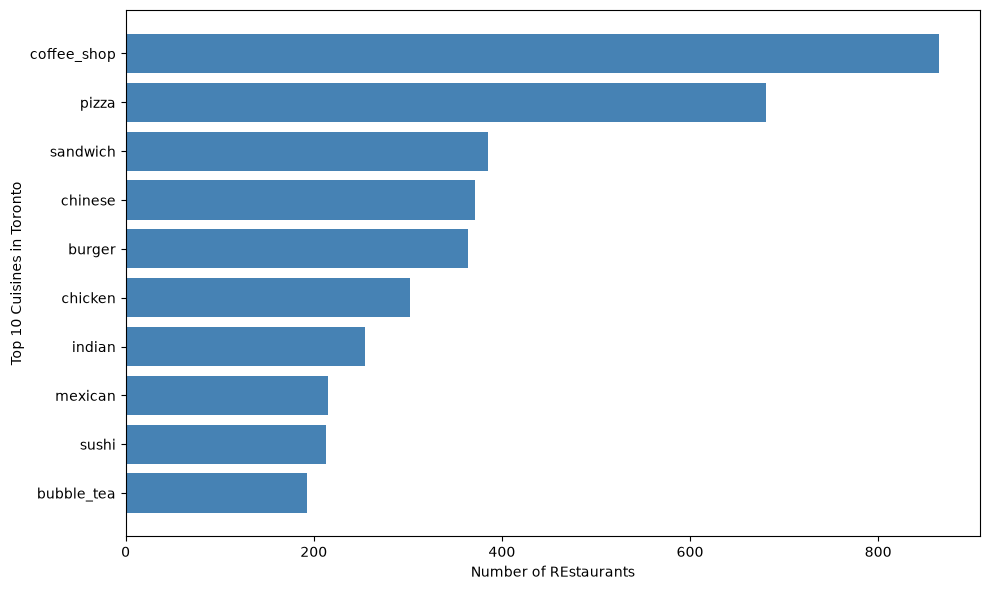

In [ ]:
# Plot top 10 cuisines 
plt.figure(figsize=(10,6))
plt.barh(df_cuisine['cuisine'], df_cuisine['total'], color='steelblue')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [10]:
# Query top 10 streets by restaurant count
query = """
    SELECT street, COUNT(*) as total
    FROM restaurants
    WHERE street IS NOT NULL
    GROUP BY street
    ORDER BY total DESC
    LIMIT 10;
"""

df_streets = pd.read_sql(query, conn)
print(df_streets)

                      street  total
0               Yonge Street    410
1          Bloor Street West    360
2          Queen Street West    255
3         Dundas Street West    254
4          Queen Street East    175
5             College Street    173
6      St. Clair Avenue West    108
7           King Street West    100
8            Danforth Avenue     96
9  Lake Shore Boulevard West     92


/var/folders/q3/lqkxfhqd69scqh0r94mkbdm00000gn/T/ipykernel_22960/3476000666.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_streets = pd.read_sql(query, conn)


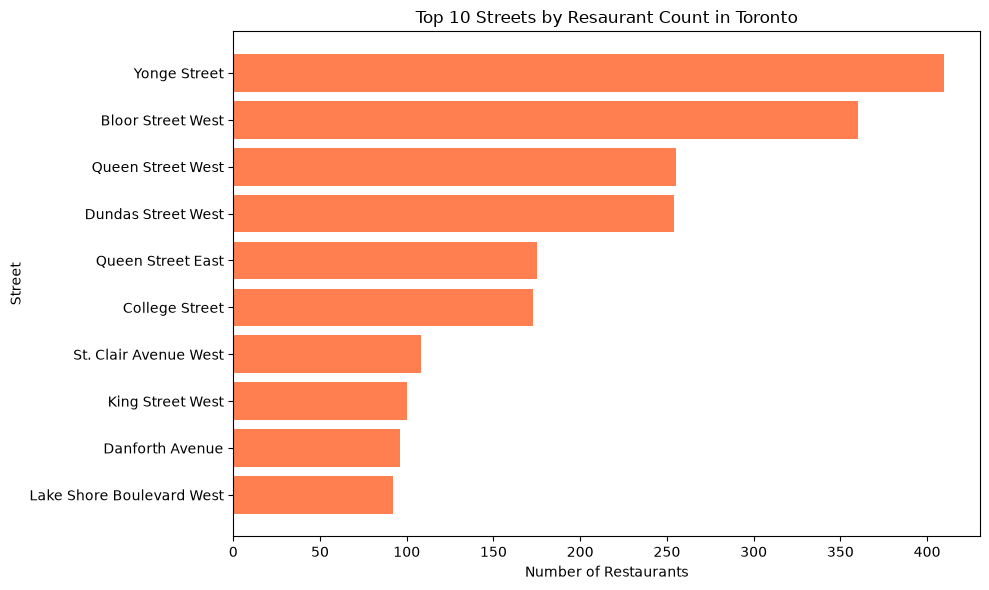

In [ ]:
# Plot top 10 Streets by restaurant count
plt.figure(figsize=(10, 6))
plt.barh(df_streets['street'], df_streets['total'], color='coral')
plt.xlabel('Number of Restaurants')
plt.ylabel('Street')
plt.title('Top 10 Streets by Restaurant Count in Toronto')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
# Query data completeness
query = """
    SELECT 
        COUNT(*) as total_rows,
        COUNT(name) as has_name, 
        COUNT(cuisine) as has_cuisine,
        COUNT(PHONE) as has_phone,
        COUNT(street) as has_street
    FROM restaurants;
"""

df_completeness = pd.read_sql(query, conn)

# Calculate percentages
total = df_completeness['total_rows'][0]

completeness = {
    'Name': df_completeness['has_name'][0] / total * 100,
    'Cuisine': df_completeness['has_cuisine'][0] / total * 100,
    'Street': df_completeness['has_street'][0] / total * 100,
    'Phone': df_completeness['has_phone'][0] / total * 100,
}

print(completeness)

{'Name': np.float64(98.39483214250758), 'Cuisine': np.float64(66.29147499265929), 'Street': np.float64(50.56278751101107), 'Phone': np.float64(22.9323676225898)}


/var/folders/q3/lqkxfhqd69scqh0r94mkbdm00000gn/T/ipykernel_22960/347939513.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_completeness = pd.read_sql(query, conn)


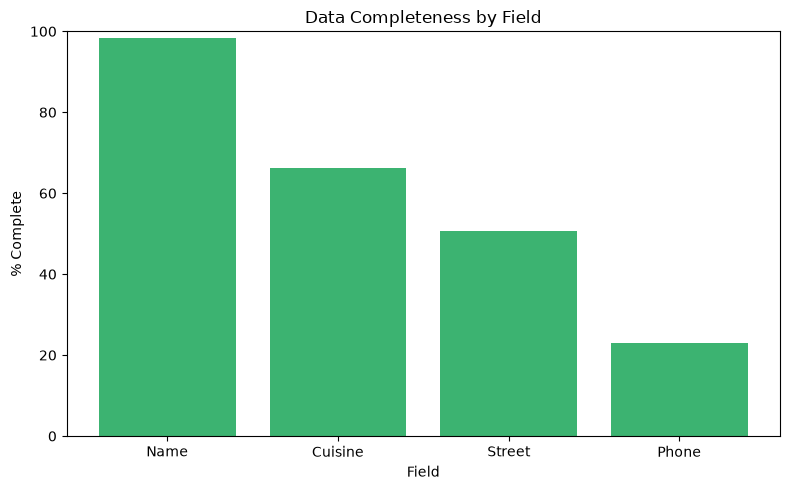

In [ ]:
# Plot data completeness
plt.figure(figsize=(8, 5))
plt.bar(completeness.keys(), completeness.values(), color='mediumseagreen')
plt.xlabel('Field')
plt.ylabel('% Complete')
plt.title('Data Completeness by Field')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [15]:
# Query restaurants near each subway station
query = """
SELECT 
    s.name as station,
    COUNT(*) as nearby_restaurants
FROM subway_stations s
JOIN restaurants r ON (
    ABS(r.lat - s.lat) < 0.005 AND
    ABS(r.lon - s.lon) < 0.007
)
GROUP BY s.name
ORDER BY nearby_restaurants DESC
LIMIT 10;
"""

df_stations = pd.read_sql(query, conn)
print(df_stations)

        station  nearby_restaurants
0    St. Andrew                 459
1       Osgoode                 445
2         Queen                 430
3         Union                 408
4          King                 402
5           TMU                 369
6       College                 352
7   St. Patrick                 334
8     Wellesley                 281
9  Queen's Park                 244


/var/folders/q3/lqkxfhqd69scqh0r94mkbdm00000gn/T/ipykernel_22960/3538433643.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_stations = pd.read_sql(query, conn)


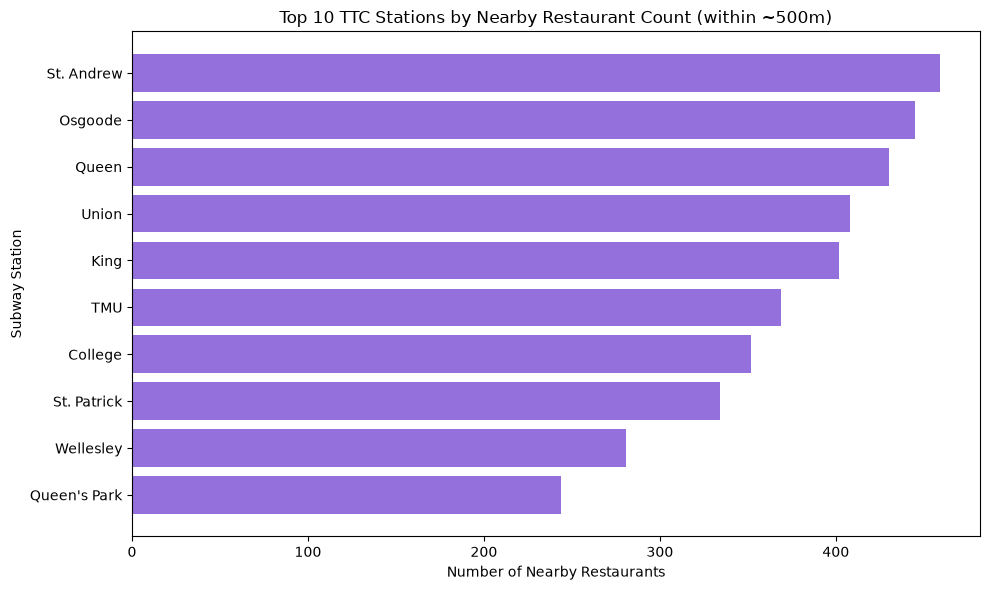

In [16]:
# Plot data
plt.figure(figsize=(10, 6))
plt.barh(df_stations['station'], df_stations['nearby_restaurants'], color='mediumpurple')
plt.xlabel('Number of Nearby Restaurants')
plt.ylabel('Subway Station')
plt.title('Top 10 TTC Stations by Nearby Restaurant Count (within ~500m)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()